## Установка PySpark

In [3]:
!apt-get update
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget -q https://downloads.apache.org/spark/spark-3.5.7/spark-3.5.7-bin-hadoop3.tgz
!tar xf spark-3.5.7-bin-hadoop3.tgz

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,153 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,491 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,539 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-bac

In [4]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.7-bin-hadoop3"

In [5]:
!pip install findspark

In [6]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

## Предобработка датасета

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.dataframe import DataFrame

In [8]:
import kagglehub
path = kagglehub.dataset_download("artermiloff/steam-games-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'steam-games-dataset' dataset.
Path to dataset files: /kaggle/input/steam-games-dataset


In [9]:
file_name = 'games_march2025_full.csv'
dataset_path = os.path.join(path, file_name)

In [10]:
steam_df = spark.read.load(dataset_path,
                      format='com.databricks.spark.csv',
                      header='true', inferSchema='true',
                      quote='"', escape='"')

In [11]:
steam_df.show()

+-------+--------------------+------------+------------+-----+---------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-----+-----+----------------+--------------------+------------+---------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+----------+--------+--------+--------------------+------------------------+-----------------------+-----------------------+----------------------+--------+--------+--------------------+-------------+-----------------+--------------+------------------+
|  appid|                name|release_date|required_age|price|dlc_count|detailed_description|      about_the_game|   short_description|             reviews|        header_image|             website|  

In [12]:
steam_df.printSchema()

root
 |-- appid: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- required_age: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- dlc_count: integer (nullable = true)
 |-- detailed_description: string (nullable = true)
 |-- about_the_game: string (nullable = true)
 |-- short_description: string (nullable = true)
 |-- reviews: string (nullable = true)
 |-- header_image: string (nullable = true)
 |-- website: string (nullable = true)
 |-- support_url: string (nullable = true)
 |-- support_email: string (nullable = true)
 |-- windows: boolean (nullable = true)
 |-- mac: boolean (nullable = true)
 |-- linux: boolean (nullable = true)
 |-- metacritic_score: integer (nullable = true)
 |-- metacritic_url: string (nullable = true)
 |-- achievements: integer (nullable = true)
 |-- recommendations: integer (nullable = true)
 |-- notes: string (nullable = true)
 |-- supported_languages: string (nullable = true)
 |-- ful

In [13]:
steam_df.describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
appid,94948,1707530.5252138013,926434.6198176217,20,3570420
name,94946,Infinity,NaN,! Shakabula *,𣸩
required_age,94948,0.17828706239204617,1.7013287876460188,-1,21
price,94948,6.911444264228297,13.071147631155524,0.0,999.98
dlc_count,94948,0.5632030163879176,14.915684797980566,0,3427
detailed_description,89522,1.0,None,! ! ! PLEASE READ BEFORE BUYING ! ! ! Active-D...,🧭 Orienteering Simulator 🧭 Version: v.1.1 Mart...
about_the_game,89499,1.0,None,! Important: 'X' key for selection and decisio...,🧭 Orienteering Simulator 🧭 Version: v.1.1 Mart...
short_description,89599,1.0,None,Hungry piggy vs Chicken: Yes! We are Hungry!...,🧩Engage in exciting puzzles with charming anim...
reviews,10428,None,None,"""ACDSee 15 is a full-featured photo editor and...",焯 – 我超 值 – Graf Spee 酥 – 不愿透露姓名的酥酥


### Заполнение пропусков в данных

In [14]:
steam_df = steam_df.replace(-1, 0, subset='required_age')

In [15]:
steam_df.describe(['required_age']).show()

+-------+-------------------+
|summary|       required_age|
+-------+-------------------+
|  count|              94948|
|   mean|0.17829759447276403|
| stddev| 1.7013245886260249|
|    min|                  0|
|    max|                 21|
+-------+-------------------+



In [16]:
steam_df = steam_df.drop(steam_df.score_rank)

In [17]:
def get_pos_to_total_relation(positive: int, negative: int, pct_pos_total: int) -> float:
  total = positive + negative
  if total == 0:
    if pct_pos_total == 0:
      return 0
    else:
      return pct_pos_total / 100
  else:
    return positive / total

def steam_rating(positive: int, negative: int, pct_pos_total: int) -> str:
  if positive == 0 and negative == 0 and pct_pos_total == 0:
    return "No reviews"
  pct = get_pos_to_total_relation(positive, negative, pct_pos_total) * 100

  if pct >= 95:
    return "Overwhelmingly Positive"
  elif pct >= 85:
    return "Very Positive"
  elif pct >= 80:
    return "Positive"
  elif pct >= 70:
    return "Mostly Positive"
  elif pct >= 40:
    return "Mixed"
  elif pct >= 20:
    return "Mostly Negative"
  elif pct >=5 :
    return "Negative"
  else:
    return "Overwhelmingly Negative"

In [18]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType, ArrayType, FloatType

relation_udf = udf(get_pos_to_total_relation, FloatType())
steam_udf = udf(steam_rating, StringType())

In [19]:
steam_df = steam_df.withColumn('rating', relation_udf('positive', 'negative', 'pct_pos_total'))
steam_df = steam_df.withColumn('rating_status', steam_udf('positive', 'negative', 'pct_pos_total'))

In [20]:
steam_df.show()

+-------+--------------------+------------+------------+-----+---------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-----+-----+----------------+--------------------+------------+---------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+--------+--------+--------------------+------------------------+-----------------------+-----------------------+----------------------+--------+--------+--------------------+-------------+-----------------+--------------+------------------+----------+--------------------+
|  appid|                name|release_date|required_age|price|dlc_count|detailed_description|      about_the_game|   short_description|             reviews|        header_image|  

In [21]:
print(f"Without review: {steam_df.filter(steam_df.rating_status == 'No reviews').count()}")
steam_df = steam_df.filter(steam_df.rating_status != 'No reviews')

Without review: 2


In [22]:
from pyspark.sql import functions as F

In [23]:
steam_df = steam_df.withColumn(
    "genres",
    F.from_json(F.col("genres"), ArrayType(StringType()))
)

steam_df = steam_df.withColumn(
    "categories",
    F.from_json(F.col("categories"), ArrayType(StringType()))
)

steam_df = steam_df.withColumn(
    "publishers",
    F.from_json(F.col("publishers"), ArrayType(StringType()))
)

steam_df = steam_df.withColumn(
    "developers",
    F.from_json(F.col("developers"), ArrayType(StringType()))
)

steam_df = steam_df.withColumn(
    "supported_languages",
    F.from_json(F.col("supported_languages"), ArrayType(StringType()))
)

In [24]:
steam_df.show()

+-------+--------------------+------------+------------+-----+---------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-----+-----+----------------+--------------------+------------+---------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+--------+--------+--------------------+------------------------+-----------------------+-----------------------+----------------------+--------+--------+--------------------+-------------+-----------------+--------------+------------------+----------+--------------------+
|  appid|                name|release_date|required_age|price|dlc_count|detailed_description|      about_the_game|   short_description|             reviews|        header_image|  

### Корреляция между признаками

In [25]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

copy = steam_df
num_cols = [c for c, t in copy.dtypes if t in ("int", "double", "float", "long")]

assembler = VectorAssembler(inputCols=num_cols, outputCol="features")

df_vec = assembler.transform(copy)

corr_matrix = Correlation.corr(df_vec, "features").head()[0]

In [26]:
num_cols

['appid',
 'required_age',
 'price',
 'dlc_count',
 'metacritic_score',
 'achievements',
 'recommendations',
 'user_score',
 'positive',
 'negative',
 'average_playtime_forever',
 'average_playtime_2weeks',
 'median_playtime_forever',
 'median_playtime_2weeks',
 'discount',
 'peak_ccu',
 'pct_pos_total',
 'num_reviews_total',
 'pct_pos_recent',
 'num_reviews_recent',
 'rating']

In [27]:
corr_array = corr_matrix.toArray()
corr_df = pd.DataFrame(corr_array, columns=num_cols, index=num_cols)

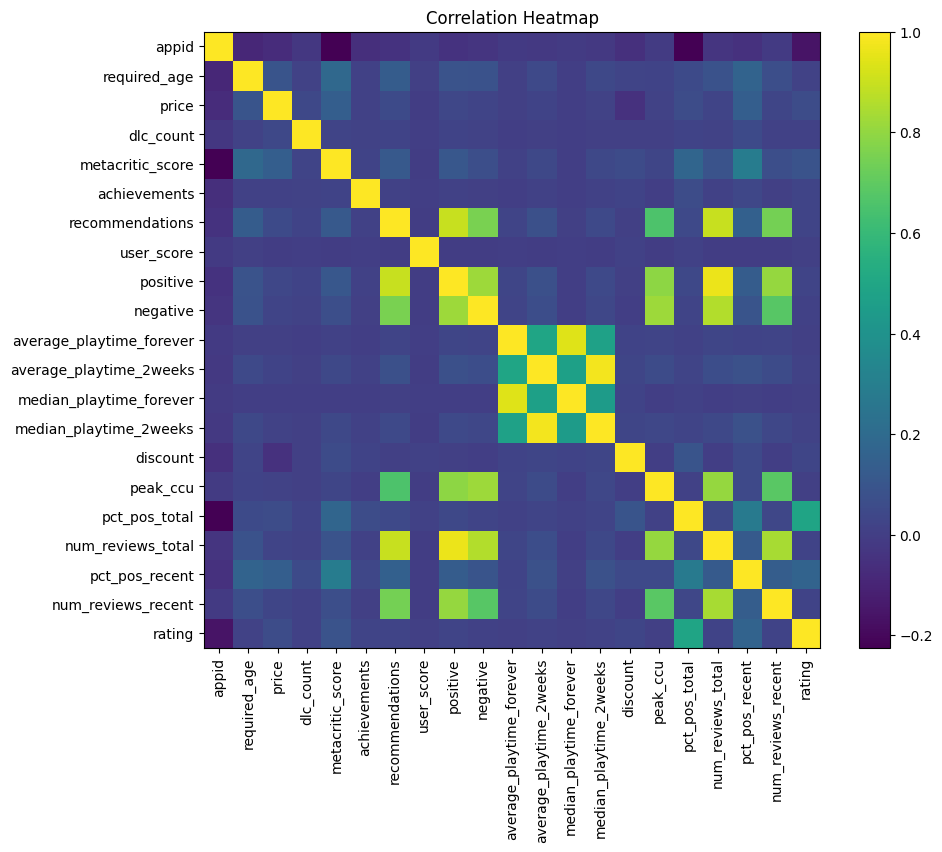

In [28]:
plt.figure(figsize=(10, 8))

plt.imshow(corr_df, cmap='viridis')
plt.colorbar()

plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)

plt.title("Correlation Heatmap")
plt.show()

In [29]:
corr_df['rating'].sort_values(ascending=False)

,rating
rating,1.000000
pct_pos_total,0.491555
pct_pos_recent,0.166559
metacritic_score,0.087372
price,0.058271
discount,0.031359
achievements,0.027023
recommendations,0.026908
positive,0.024489
num_reviews_total,0.022613


### Выбросы

In [40]:
pandas_df = steam_df.select(num_cols).toPandas()

In [41]:
pandas_df

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,positive,negative,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,rating
0,730,0,0.00,1,0,1,4401572,0,7480813,1135108,...,879,5174,350,0,1212356,86,8632939,82,96473,0.868255
1,578080,0,0.00,0,0,37,1732007,0,1487960,1024436,...,0,0,0,0,616738,59,2513842,68,16720,0.592247
2,570,0,0.00,2,90,0,14337,0,1998462,451338,...,1536,898,892,0,555977,81,2452595,80,29366,0.815765
3,271590,17,0.00,0,96,77,1803063,0,1719950,250012,...,771,7101,74,0,117698,87,1803832,92,17517,0.873088
4,488824,17,19.99,9,0,0,1160724,0,312816,64201,...,0,0,0,0,0,84,1168404,76,13017,0.829713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94941,2115110,0,3.99,0,0,6,0,0,2,0,...,0,0,0,0,0,-1,-1,-1,-1,1.000000
94942,1174200,0,10.00,0,0,0,0,0,2,0,...,0,0,0,0,0,-1,-1,-1,-1,1.000000
94943,1160190,0,1.99,0,0,0,0,0,2,1,...,0,0,0,0,0,-1,-1,-1,-1,0.666667
94944,3380340,0,29.99,0,0,34,0,0,2,0,...,0,0,0,0,0,-1,-1,-1,-1,1.000000


/tmp/ipython-input-3994399294.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pandas_df[c] for c in pandas_df.columns], labels=pandas_df.columns)


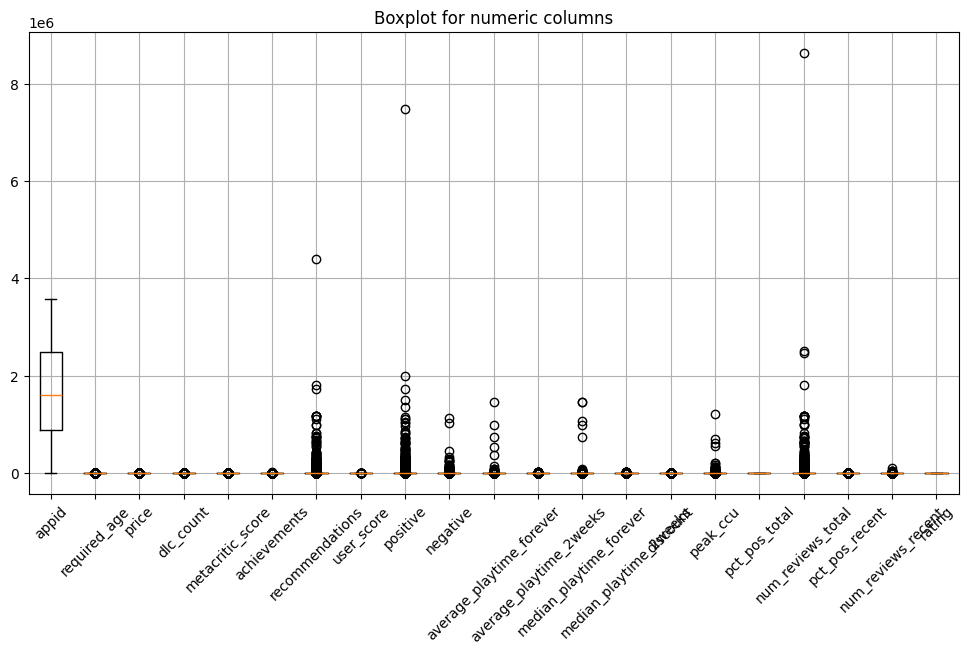

In [42]:
plt.figure(figsize=(12, 6))
plt.boxplot([pandas_df[c] for c in pandas_df.columns], labels=pandas_df.columns)
plt.xticks(rotation=45)
plt.title("Boxplot for numeric columns")
plt.grid()
plt.show()

/tmp/ipython-input-175145775.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(pandas_df['price'], labels=['Price'])
/tmp/ipython-input-175145775.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


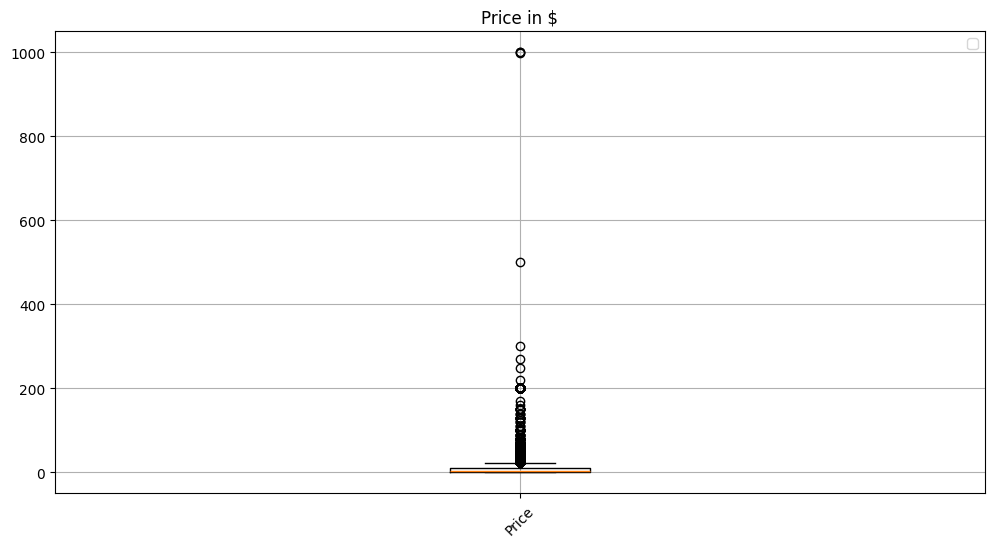

In [43]:
plt.figure(figsize=(12, 6))
plt.boxplot(pandas_df['price'], labels=['Price'])
plt.xticks(rotation=45)
plt.title("Price in $")
plt.legend()
plt.grid()
plt.show()

/tmp/ipython-input-225064941.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(pandas_df['required_age'], labels=['required_age'])
/tmp/ipython-input-225064941.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


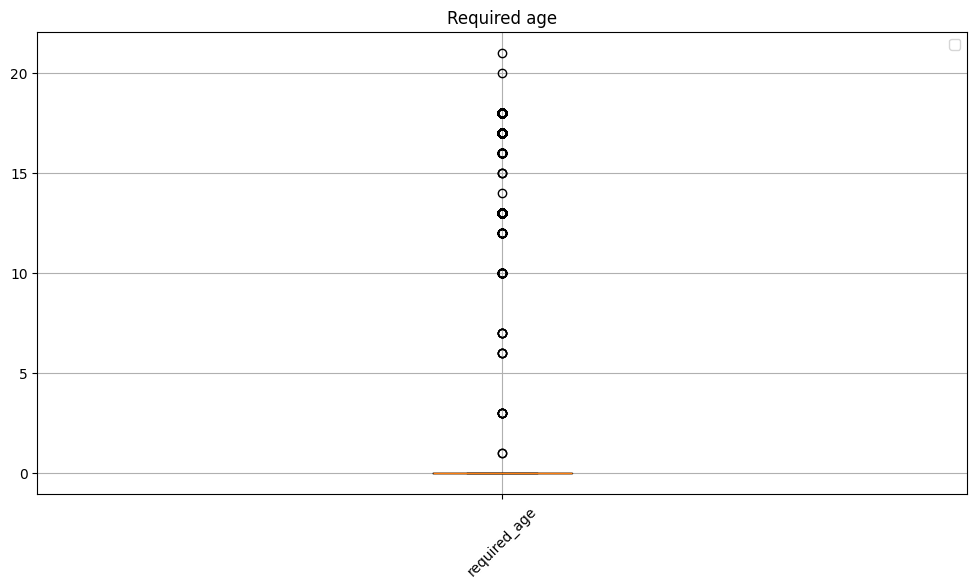

In [44]:
plt.figure(figsize=(12, 6))
plt.boxplot(pandas_df['required_age'], labels=['required_age'])
plt.xticks(rotation=45)
plt.title("Required age")
plt.legend()
plt.grid()
plt.show()

### Оценка рейтинга

In [30]:
df_agregation = steam_df.agg(
    F.sum((steam_df.rating >= 0.8).cast("int")).alias("positive"),
    F.sum((steam_df.rating < 0.8).cast("int")).alias("negative")
    )

In [31]:
df_agregation.show()

+--------+--------+
|positive|negative|
+--------+--------+
|   45044|   49902|
+--------+--------+



In [32]:
steam_df = steam_df.withColumn('IsPositive', F.when(F.col('rating') >= 0.8, 1).otherwise(0))

### Масштабирование

In [33]:
def z_normalize_value(df: DataFrame, column_name: str) -> DataFrame:
  stats = df.select(
    F.mean(column_name).alias("mean"),
    F.stddev(column_name).alias("std")
  ).first()

  mean_val = stats["mean"]
  std_val = stats["std"]

  df_z = df.withColumn(column_name, (F.col(column_name) - mean_val) / std_val)
  return df_z

def normalize(df: DataFrame, columns: list[str]) -> DataFrame:
  norm_df = df
  for column_name in columns:
    norm_df = z_normalize_value(norm_df, column_name)
  return norm_df

def minmax_normalization(df: DataFrame, column_name: str) -> DataFrame:
  stats = df.select(
    F.min(column_name).alias("min"),
    F.max(column_name).alias("max")
  ).first()

  min_val = stats["min"]
  max_val = stats["max"]

  df_norm = df.withColumn(column_name, (F.col(column_name) - min_val) / (max_val - min_val))
  return df_norm

In [34]:
columns = ['price', 'dlc_count', 'metacritic_score', 'achievements', 'recommendations', 'average_playtime_forever', 'peak_ccu', 'rating']
normalized = normalize(steam_df, columns)
normalized = minmax_normalization(normalized, 'required_age')

In [35]:
normalized.show()

+-------+--------------------+------------+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-----+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+--------+--------+--------------------+------------------------+-----------------------+-----------------------+----------------------+--------+--------------------+--------------------+-------------+-----------------+--------------+------------------+--------------------+--------------------+----------+
|  appid|                name|release_date|      required_age|               price|           dlc

In [36]:
normalized.describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
appid,94946,1707506.9186484949,926426.3635525969,20,3570420
name,94944,Infinity,NaN,! Shakabula *,𣸩
required_age,94946,0.008490540487675655,0.08101630051336424,0.0,1.0
price,94946,4.765589009879635E-14,1.0000000000000009,-0.528751815591271,75.97335942817377
dlc_count,94946,9.684443193946353E-15,1.0000000000000004,-0.03775951048875179,229.71796433763564
detailed_description,89520,1.0,None,! ! ! PLEASE READ BEFORE BUYING ! ! ! Active-D...,🧭 Orienteering Simulator 🧭 Version: v.1.1 Mart...
about_the_game,89497,1.0,None,! Important: 'X' key for selection and decisio...,🧭 Orienteering Simulator 🧭 Version: v.1.1 Mart...
short_description,89597,1.0,None,Hungry piggy vs Chicken: Yes! We are Hungry!...,🧩Engage in exciting puzzles with charming anim...
reviews,10428,None,None,"""ACDSee 15 is a full-featured photo editor and...",焯 – 我超 值 – Graf Spee 酥 – 不愿透露姓名的酥酥


### Категориальные признаки

In [37]:
def get_all_from_list(dataset: DataFrame, column_name: str) -> list[str]:
  all_categories = (
      dataset.select(F.explode(column_name).alias("category"))
        .distinct()
        .rdd.map(lambda r: r["category"])
        .collect()
  )
  return all_categories
all_genres = get_all_from_list(steam_df, 'genres')
all_categories = get_all_from_list(steam_df, 'categories')
all_developers = get_all_from_list(steam_df, 'developers')
all_publishers = get_all_from_list(steam_df, 'publishers')
all_supported_languages = get_all_from_list(steam_df, 'supported_languages')

In [38]:
print(f"Genres (total: {len(all_genres)}): ", all_genres)
print(f"Categories (total: {len(all_categories)}): ", all_categories)
print(f"Supported languages (total: {len(all_supported_languages)}): ", all_supported_languages)
print(f"Developers (total: {len(all_developers)}): ", all_developers)
print(f"Publishers (total: {len(all_publishers)}): ", all_publishers)

Genres (total: 33):  ['Education', 'Massively Multiplayer', 'Sexual Content', 'Adventure', 'Sports', 'Accounting', 'Audio Production', 'Video Production', 'Animation & Modeling', 'Racing', 'Gore', 'Design & Illustration', 'Software Training', 'Web Publishing', 'Violent', 'Utilities', 'Game Development', 'Movie', 'Nudity', 'Early Access', 'Casual', 'Free To Play', 'Action', 'Strategy', 'Indie', 'RPG', 'Simulation', 'Photo Editing', 'Documentary', 'Episodic', '360 Video', 'Short', 'Tutorial']
Categories (total: 40):  ['Cross-Platform Multiplayer', 'Includes Source SDK', 'Remote Play on TV', 'Steam Workshop', 'Steam Cloud', 'Commentary available', 'In-App Purchases', 'Stats', 'Includes level editor', 'Remote Play on Tablet', 'SteamVR Collectibles', 'Steam Turn Notifications', 'Remote Play Together', 'Online PvP', 'Partial Controller Support', 'VR Only', 'LAN PvP', 'Steam Timeline', 'Family Sharing', 'Full controller support', 'Multi-player', 'Online Co-op', 'Steam Trading Cards', 'Valve A

In [39]:
def one_hot_encoding(df: DataFrame, categories: list[str], column_name: str, new_columns_prefix: str) -> DataFrame:
  result_df = df
  for category_name in categories:
    result_df = result_df.withColumn(f"{new_columns_prefix}_{category_name}",
                                     F.when(F.array_contains(column_name, category_name), 1).otherwise(0))
  return result_df

In [40]:
encoded = one_hot_encoding(normalized, all_genres, "genres", "genre")
encoded = one_hot_encoding(encoded, all_categories, "categories", "category")

In [41]:
encoded = encoded.withColumn('languages_count', F.array_size('supported_languages'))
encoded = minmax_normalization(encoded, 'languages_count')
encoded.show()

+-------+--------------------+------------+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-----+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+--------+--------+--------------------+------------------------+-----------------------+-----------------------+----------------------+--------+--------------------+--------------------+-------------+-----------------+--------------+------------------+--------------------+--------------------+----------+---------------+---------------------------+--------------------+---------------+------------+----

#### Анализ колличества разработчиков

In [86]:
df_exploded = steam_df.withColumn("developer", F.explode("developers"))
df_counts = (
    df_exploded
    .groupBy("developer")
    .agg(F.count("*").alias("num_games"))
)

In [87]:
df_multi = df_counts.filter(F.col("num_games") > 1)

In [88]:
df_multi.show()

+--------------------+---------+
|           developer|num_games|
+--------------------+---------+
|      11 bit studios|        8|
| Double Damage Games|        2|
|          FELISTELLA|        2|
|            Double W|        5|
|           Morteshka|        2|
|     Harvester Games|        4|
|  Drift Physics Crew|        2|
|           IR Studio|       64|
|         Ino-Co Plus|        6|
|  Littlefield Studio|        2|
|               Karne|        2|
|          O-TWO inc.|        7|
|Morningstar Game ...|        3|
|  Alzan Studios, LLC|        3|
|            uglycoal|        3|
|        Blazes Games|        2|
|            mc2games|        8|
|        Matt Workman|        3|
|               Tyler|        2|
|        Costek Games|        2|
+--------------------+---------+
only showing top 20 rows



In [90]:
df_distribution = (
    df_counts
    .groupBy("num_games")
    .agg(F.count("*").alias("num_developers"))
    .orderBy("num_games")
    .toPandas()
)


In [99]:
df_distribution

,num_games,num_developers
0,1,46436
1,2,7509
2,3,2726
3,4,1159
4,5,656
...,...,...
74,124,1
75,133,1
76,140,1
77,158,1


In [102]:
df12 = df_distribution[df_distribution['num_games']>20]
print(df12['num_developers'].sum())

184


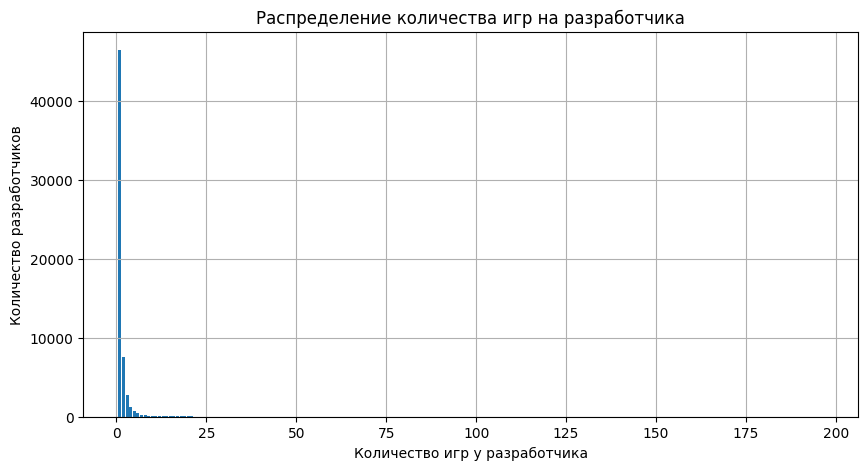

In [109]:
plt.figure(figsize=(10, 5))
plt.bar(df_distribution["num_games"], df_distribution["num_developers"])
plt.xlabel("Количество игр у разработчика")
plt.ylabel("Количество разработчиков")
plt.title("Распределение количества игр на разработчика")
plt.grid()
plt.show()

#### Bolean столбцы

In [42]:
encoded = encoded.withColumn("is_windows", F.col("windows").cast("int"))
encoded = encoded.withColumn("is_mac", F.col("mac").cast("int"))
encoded = encoded.withColumn("is_linux", F.col("linux").cast("int"))

### Удаление столбцов

In [43]:
drop_columns = ['appid', 'name', 'release_date', 'detailed_description', 'about_the_game', 'short_description',
'header_image', 'reviews', 'website', 'support_url', 'support_email', 'metacritic_url', 'notes',
                'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers',
                'categories', 'genres', 'screenshots', 'movies', 'user_score', 'positive', 'negative',
                'estimated_owners', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks',
                'discount', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent',
                'windows', 'mac', 'linux', 'rating_status', 'rating']

In [44]:
dropped = encoded
for column in drop_columns:
  dropped = dropped.drop(column)
dropped.show()

+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------------+--------------------+----------+---------------+---------------------------+--------------------+---------------+------------+----------------+----------------------+----------------------+--------------------------+------------+----------+---------------------------+-----------------------+--------------------+-------------+---------------+----------------------+-----------+------------+------------------+------------+------------------+------------+--------------+-----------+---------+----------------+-------------------+-----------------+--------------+---------------+-----------+--------------+-----------------------------------+----------------------------+--------------------------+-----------------------+--------------------+-----------------------------+-------------------------+--------------+------------------------------+------

### Итоговая корреляция

In [45]:
def get_correlation_matrix(df):
  num_cols = [c for c, t in df.dtypes if t in ("int", "double", "float", "long")]
  assembler = VectorAssembler(inputCols=num_cols, outputCol="features")
  df_vec = assembler.transform(df)
  corr_matrix = Correlation.corr(df_vec, "features").head()[0]
  corr_array = corr_matrix.toArray()
  corr_df = pd.DataFrame(corr_array, columns=num_cols, index=num_cols)
  return corr_df, num_cols

In [46]:
corr_df, num_cols = get_correlation_matrix(dropped)

In [47]:
def plot_correlation_matrix(corr_df, num_cols):
  plt.figure(figsize=(16, 13))
  plt.imshow(corr_df, cmap='viridis')
  plt.colorbar()
  plt.xticks(range(len(num_cols)), num_cols, rotation=90)
  plt.yticks(range(len(num_cols)), num_cols)
  plt.grid()
  plt.title("Correlation Heatmap")
  plt.show()

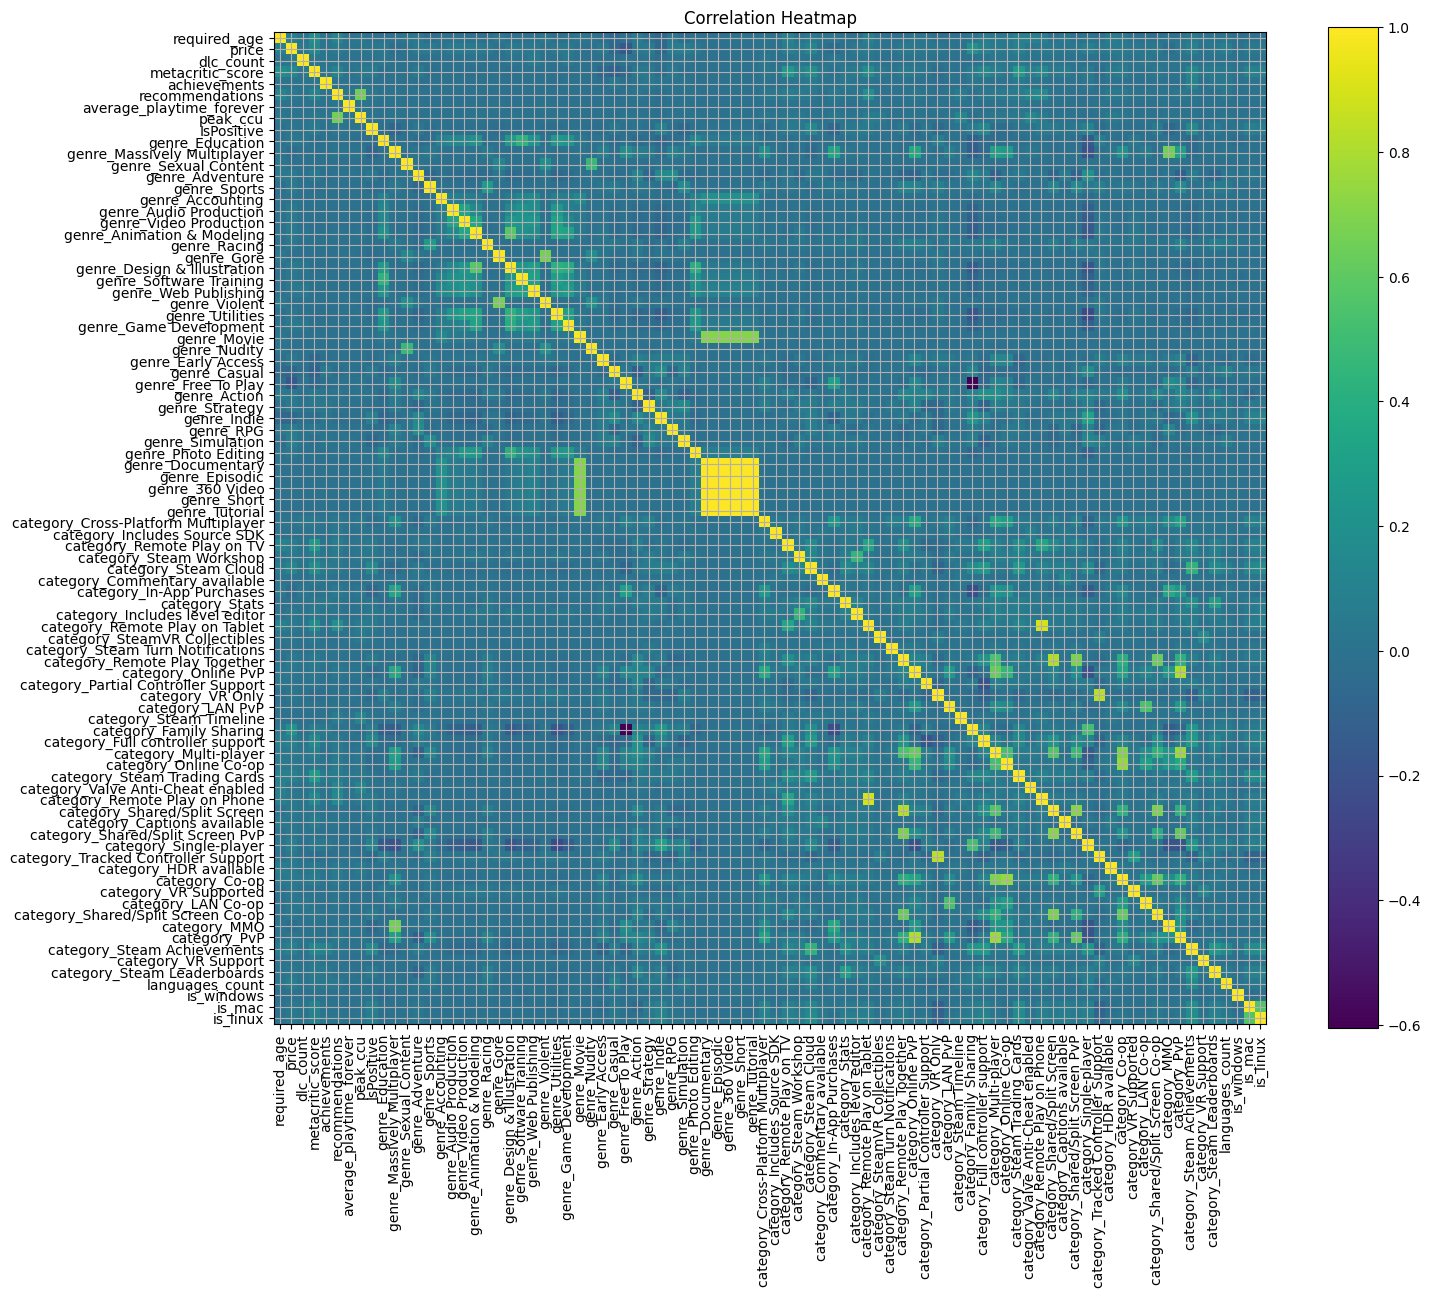

In [48]:
plot_correlation_matrix(corr_df, num_cols)

In [50]:
corr_df['IsPositive'].sort_values(ascending=False)

,IsPositive
IsPositive,1.000000
category_Steam Cloud,0.150923
category_Steam Achievements,0.148701
category_Full controller support,0.141305
category_Single-player,0.118241
...,...
category_VR Only,-0.048056
category_MMO,-0.063997
genre_Simulation,-0.066053
category_In-App Purchases,-0.072903


In [51]:
also_drop_columns = ['genre_Episodic', 'genre_360 Video',
                     'genre_Short', 'genre_Tutorial']
final_df = dropped
for column in also_drop_columns:
  final_df = final_df.drop(column)

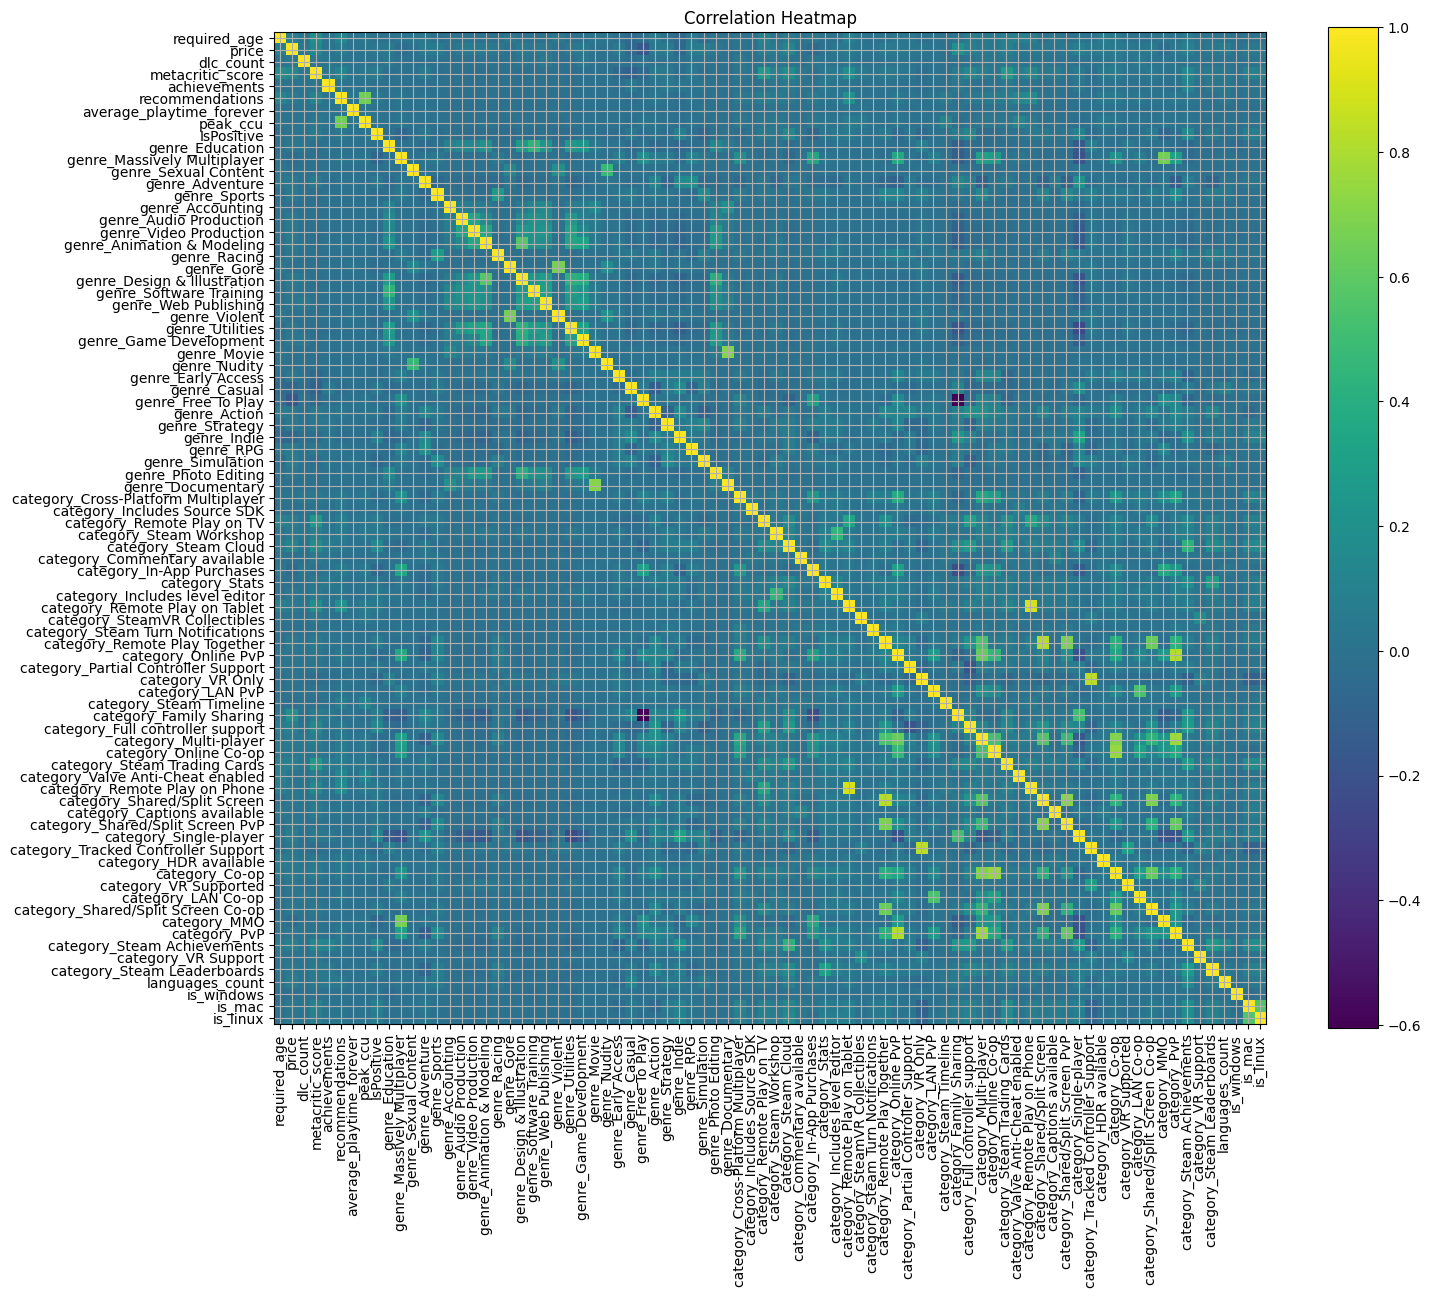

In [52]:
corr_df2, num_cols2 = get_correlation_matrix(final_df)
plot_correlation_matrix(corr_df2, num_cols2)

## Классификация

In [81]:
feature_cols = final_df.columns
feature_cols.remove('IsPositive')
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled = assembler.transform(final_df)
(trainingData, testData) = assembled.randomSplit([0.8,0.2], seed = 13234 )

In [82]:
trainingData.count(), testData.count()

(76079, 18867)

In [70]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [88]:
evaluator = MulticlassClassificationEvaluator(). \
    setLabelCol("IsPositive"). \
    setPredictionCol("prediction"). \
    setMetricName("accuracy")

In [102]:
def calculate_metrics(evaluator, prediction):
  accuracy = evaluator.evaluate(prediction)
  tp = prediction[(prediction.IsPositive == 1) & (prediction.prediction == 1)].count()
  tn = prediction[(prediction.IsPositive == 0) & (prediction.prediction == 0)].count()
  fp = prediction[(prediction.IsPositive == 0) & (prediction.prediction == 1)].count()
  fn = prediction[(prediction.IsPositive == 1) & (prediction.prediction == 0)].count()

  print("True Positives:", tp)
  print("True Negatives:", tn)
  print("False Positives:", fp)
  print("False Negatives:", fn)
  print("Total", prediction.count(), '\n')
  print(f"Confusion Matrix:\n{tp:>4}\t{fp:>4}\n{fn:>4}\t{tn:>4}", '\n')

  print("accuracy", accuracy)
  recall = float(tp)/(tp + fn)
  print("recall", recall)

  precision = float(tp)/(tp + fp)
  print("precision", precision)
  return accuracy, recall, precision


### Decision Tree 🌲

In [77]:
from pyspark.ml.classification import DecisionTreeClassifier

In [93]:
dt = DecisionTreeClassifier(labelCol="IsPositive", featuresCol="features", predictionCol="prediction", maxDepth=5,
                            minInstancesPerNode=20, impurity="gini")

In [103]:
dt_pipeline = Pipeline(stages=[dt])
dt_model = dt_pipeline.fit(trainingData)

In [106]:
from pyspark.ml.tuning import ParamGridBuilder

paramGrid_with_optimization = ParamGridBuilder(). \
    addGrid(dt.impurity, ["gini", "entropy"]). \
    addGrid(dt.maxDepth, [5, 8, 10]). \
    addGrid(dt.maxBins, [20, 30]). \
    addGrid(dt.minInfoGain, [0.0]). \
    build()


In [109]:
from pyspark.ml.tuning import TrainValidationSplit
pipeline_with_optimization = dt_pipeline
validator = TrainValidationSplit(seed=1234, estimator=pipeline_with_optimization, evaluator=evaluator, estimatorParamMaps=paramGrid_with_optimization, trainRatio=0.9)
model_with_optimization = validator.fit(trainingData)

In [110]:
metrics = model_with_optimization.validationMetrics
params = model_with_optimization.getEstimatorParamMaps()
metrics_and_params = list(zip(metrics, params))
metrics_and_params.sort(key=lambda x: x[0], reverse=True)

metrics_and_params

[(0.6213770491803279,
  {Param(parent='DecisionTreeClassifier_24ae96f29faf', name='impurity', doc='Criterion used for information gain calculation (case-insensitive). Supported options: entropy, gini'): 'gini',
   Param(parent='DecisionTreeClassifier_24ae96f29faf', name='maxDepth', doc='Maximum depth of the tree. (>= 0) E.g., depth 0 means 1 leaf node; depth 1 means 1 internal node + 2 leaf nodes. Must be in range [0, 30].'): 10,
   Param(parent='DecisionTreeClassifier_24ae96f29faf', name='maxBins', doc='Max number of bins for discretizing continuous features.  Must be >=2 and >= number of categories for any categorical feature.'): 30,
   Param(parent='DecisionTreeClassifier_24ae96f29faf', name='minInfoGain', doc='Minimum information gain for a split to be considered at a tree node.'): 0.0}),
 (0.6212459016393442,
  {Param(parent='DecisionTreeClassifier_24ae96f29faf', name='impurity', doc='Criterion used for information gain calculation (case-insensitive). Supported options: entropy, g

In [115]:
dt_prediction = model_with_optimization.transform(testData).select("IsPositive", "prediction")

In [116]:
dt_prediction.show()

+----------+----------+
|IsPositive|prediction|
+----------+----------+
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
|         0|       0.0|
+----------+----------+
only showing top 20 rows



In [117]:
dt_accuracy, dt_recall, dt_precision =  calculate_metrics(evaluator, dt_prediction)

True Positives: 4936
True Negatives: 6929
False Positives: 3017
False Negatives: 3985
Total 18867 

Confusion Matrix:
4936	3017
3985	6929 

accuracy 0.6288758149149308
recall 0.5533011994171058
precision 0.6206462969948447


### Random Forest 🌳🌳🌳

In [118]:
from pyspark.ml.classification import RandomForestClassifier

rf_classifier = RandomForestClassifier().setLabelCol("IsPositive").setFeaturesCol("features").setPredictionCol("prediction")

rf_pipeline = Pipeline(stages=[rf_classifier])

In [119]:
rf_paramGrid = ParamGridBuilder(). \
    addGrid(rf_classifier.impurity, ["gini"]). \
    addGrid(rf_classifier.maxDepth, [5]). \
    addGrid(rf_classifier.maxBins, [20]). \
    addGrid(rf_classifier.minInfoGain, [0.0]). \
    addGrid(rf_classifier.numTrees, [2, 4, 6]). \
    build()

In [122]:
validator = TrainValidationSplit(seed=1234, estimator=rf_pipeline, evaluator=evaluator, estimatorParamMaps=rf_paramGrid, trainRatio=0.8)
rf_model = validator.fit(trainingData)


In [123]:
rf_prediction = rf_model.transform(testData)\
    .select("features", "IsPositive", "prediction")

In [124]:
rf_accuracy, rf_recall, rf_precision =  calculate_metrics(evaluator, rf_prediction)

True Positives: 3427
True Negatives: 7714
False Positives: 2232
False Negatives: 5494
Total 18867 

Confusion Matrix:
3427	2232
5494	7714 

accuracy 0.5905019345947952
recall 0.3841497589956283
precision 0.6055840254461919


### Factorization Machines 🚜

In [125]:
from pyspark.ml.classification import FMClassifier
from pyspark.ml import Pipeline

In [126]:
fm = FMClassifier(
    labelCol="IsPositive",
    featuresCol="features",
    factorSize=8,
    regParam=0.001,
    stepSize=0.01,
    maxIter=100
)

In [127]:
fm_paramGrid = (ParamGridBuilder()
    .addGrid(fm.factorSize, [8, 16])
    .addGrid(fm.stepSize, [0.01, 0.05])
    .addGrid(fm.regParam, [0.0001, 0.001])
    .addGrid(fm.maxIter, [50, 100])
    .build()
)

In [128]:
fm_pipeline = Pipeline(stages=[fm])
validator = TrainValidationSplit(seed=1234, estimator=fm_pipeline, evaluator=evaluator, estimatorParamMaps=fm_paramGrid, trainRatio=0.8)
fm_model = validator.fit(trainingData)

In [129]:
fm_predictions = fm_model.transform(testData).select("prediction", "IsPositive")

In [130]:
fm_accuracy, fm_recall, fm_precision =  calculate_metrics(evaluator, fm_predictions)

True Positives: 4950
True Negatives: 6864
False Positives: 3082
False Negatives: 3971
Total 18867 

Confusion Matrix:
4950	3082
3971	6864 

accuracy 0.6261726824614406
recall 0.5548705302096177
precision 0.6162848605577689


### Сравнение моделей

In [135]:
print('model', '\t\t', 'accuracy', '\t\t', 'recall', '\t\t', 'precision', '\n',
      "Decision Tree", '\t', dt_accuracy, '\t', dt_recall,'\t', dt_precision, '\n',
      "Random Forest", '\t', rf_accuracy, '\t', rf_recall,'\t', rf_precision, '\n',
      "F Machines", '\t', fm_accuracy, '\t', fm_recall,'\t', fm_precision)

model 		 accuracy 		 recall 		 precision 
 Decision Tree 	 0.6288758149149308 	 0.5533011994171058 	 0.6206462969948447 
 Random Forest 	 0.5905019345947952 	 0.3841497589956283 	 0.6055840254461919 
 F Machines 	 0.6261726824614406 	 0.5548705302096177 	 0.6162848605577689
